## Waze's Predict User Churn Project

**Regression Analysis**

$Task:$ To build a binomial logistic regression model to predict user churn on a variety of variables.

*1. Imports and Data Loading*

In [1]:
#Packages for numerics + dataframes
import os
import pandas as pd
import numpy as np

#Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Packages for Logistic Regression & Confusion Matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression

In [2]:
#Load the dataset by running this cell
get_cwd = os.getcwd()
df = pd.read_csv(get_cwd + '/waze_dataset.csv')

2a. EDA

In [3]:
#Shape
df.shape

(14999, 13)

In [4]:
#Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


The `label` column is missing 700 values.

In [5]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [6]:
#Checking the class imbalance of label
df['label'].value_counts(normalize=True)*100

label
retained    82.264494
churned     17.735506
Name: proportion, dtype: float64

In [7]:
#Basic statistics
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


Columns like sessions, drives, total_sessions, total_navigation_fav1, total_navigation_fav2, driven_km_drives, duration_minutes_drives seem to have outliers.

All of these columns have max values that are multiple standard deviations above the 75th percentile. This could indicate outliers in these variables.

*2b. Create Features*

In [8]:
#1. km_per_driving_day

#Create `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']
#Call `describe()` on the new column
df['km_per_driving_day'].describe()

c:\Users\222817\anaconda3\envs\minimal_ds\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

In [9]:
#Convert infinite values to zero
df.loc[df['km_per_driving_day'] == np.inf, 'km_per_driving_day'] = 0
#Confirm that it worked
df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

In [10]:
#2. professional_driver

# Create `professional_driver` column
df['profession_driver'] = np.where((df['drives'] >= 60) & (df['driving_days'] >= 15), 1, 0)

In [11]:
#Check count of professionals and non-professionals
print(df['profession_driver'].value_counts())

#Check in-class churn rate
df.groupby(['profession_driver'])['label'].value_counts(normalize=True)*100

profession_driver
0    12405
1     2594
Name: count, dtype: int64


profession_driver  label   
0                  retained    80.120227
                   churned     19.879773
1                  retained    92.443730
                   churned      7.556270
Name: proportion, dtype: float64

The churn rate for professional drivers is 7.6%, while the churn rate for non-professionals is 19.9%. This seems like it could add predictive signal to the model.

*3a. Preparing Variables*

In [12]:
#label info
df['label'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 14999 entries, 0 to 14998
Series name: label
Non-Null Count  Dtype 
--------------  ----- 
14299 non-null  object
dtypes: object(1)
memory usage: 117.3+ KB


In [13]:
#Drop rows with missing data in `label` column
df.dropna(subset=['label'])

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,profession_driver
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267,1
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,1246.901868,0
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602,0
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374,0
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,14994,retained,60,55,207.875622,140,317,0,2890.496901,2186.155708,25,17,iPhone,170.029229,0
14995,14995,retained,42,35,187.670313,2505,15,10,4062.575194,1208.583193,25,20,Android,203.128760,0
14996,14996,retained,273,219,422.017241,1873,17,0,3097.825028,1031.278706,18,17,iPhone,182.225002,1
14997,14997,churned,149,120,180.524184,3150,45,0,4051.758549,254.187763,6,6,iPhone,675.293092,0


In [14]:
#Impute Outliers
for column in ['sessions', 'drives', 'total_sessions', 'total_navigations_fav1', 
                'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives']:
    threshold = df[column].quantile(0.95)
    df.loc[df[column] > threshold, column] = threshold 

In [15]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,profession_driver
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,76.568705,64.058204,184.031320,1749.837789,114.415228,27.214281,3939.632764,1789.647426,15.537102,12.179879,578.963113,0.172945
std,4329.982679,67.297958,55.306924,118.600463,1008.513876,124.686795,36.735583,2216.041510,1222.705167,9.004655,7.824036,1030.094384,0.378212
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,136.238895,0.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,272.889272,0.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,558.686918,0.000000
max,14998.000000,243.000000,201.000000,454.363204,3500.000000,424.000000,124.000000,8889.794236,4668.899349,31.000000,30.000000,15420.234110,1.000000


In [16]:
#Encode categorical variables

#Create binary `label2` column
df['label2'] = np.where(df['label'] == 'churned', 1, 0)
df[['label', 'label2']]

,label,label2
0,retained,0
1,retained,0
2,retained,0
3,retained,0
4,retained,0
...,...,...
14994,retained,0
14995,retained,0
14996,retained,0
14997,churned,1


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
 13  km_per_driving_day       14999 non-null  float64
 14  profession_driver     

*3b. Determine whether assumptions have been met.*

* Independent observations (This refers to how the data was collected.)

* No extreme outliers

* Little to no multicollinearity among X predictors

* Linear relationship between X and the logit of y

For the first assumption, you can assume that observations are independent for this project.

The second assumption has already been addressed.

The last assumption will be verified after modeling.

In [18]:
#For collinearity

#Generate a correlation matrix
df.corr(method='pearson', numeric_only=True)

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,profession_driver,label2
ID,1.000000,0.010622,0.009740,0.002722,-0.005673,0.001089,-0.003190,-0.000773,0.000236,-0.001887,-0.001808,-0.007003,0.011884,0.004777
sessions,0.010622,1.000000,0.996907,0.595796,0.006480,0.003123,0.009746,0.001425,-0.005364,0.024374,0.018518,-0.011099,0.443151,0.033695
drives,0.009740,0.996907,1.000000,0.593945,0.006198,0.002307,0.010365,0.001789,-0.004763,0.023821,0.018036,-0.010609,0.443705,0.034528
total_sessions,0.002722,0.595796,0.593945,1.000000,0.005328,0.002377,0.008061,-0.000835,-0.001456,0.015932,0.012568,-0.014563,0.254599,0.022467
n_days_after_onboarding,-0.005673,0.006480,0.006198,0.005328,1.000000,0.001232,-0.007468,-0.002852,-0.009140,-0.009725,-0.008563,0.011631,0.001364,-0.124711
total_navigations_fav1,0.001089,0.003123,0.002307,0.002377,0.001232,1.000000,0.002467,-0.007898,0.002722,0.012176,0.011339,-0.002056,0.001135,0.051766
total_navigations_fav2,-0.003190,0.009746,0.010365,0.008061,-0.007468,0.002467,1.000000,0.003831,-0.000951,-0.003489,0.003197,0.004308,0.006892,0.014263
driven_km_drives,-0.000773,0.001425,0.001789,-0.000835,-0.002852,-0.007898,0.003831,1.000000,0.690996,-0.005620,-0.007816,0.343509,0.000219,0.020131
duration_minutes_drives,0.000236,-0.005364,-0.004763,-0.001456,-0.009140,0.002722,-0.000951,0.690996,1.000000,-0.005852,-0.007585,0.238133,-0.010022,0.040527
activity_days,-0.001887,0.024374,0.023821,0.015932,-0.009725,0.012176,-0.003489,-0.005620,-0.005852,1.000000,0.947706,-0.397062,0.452947,-0.295190


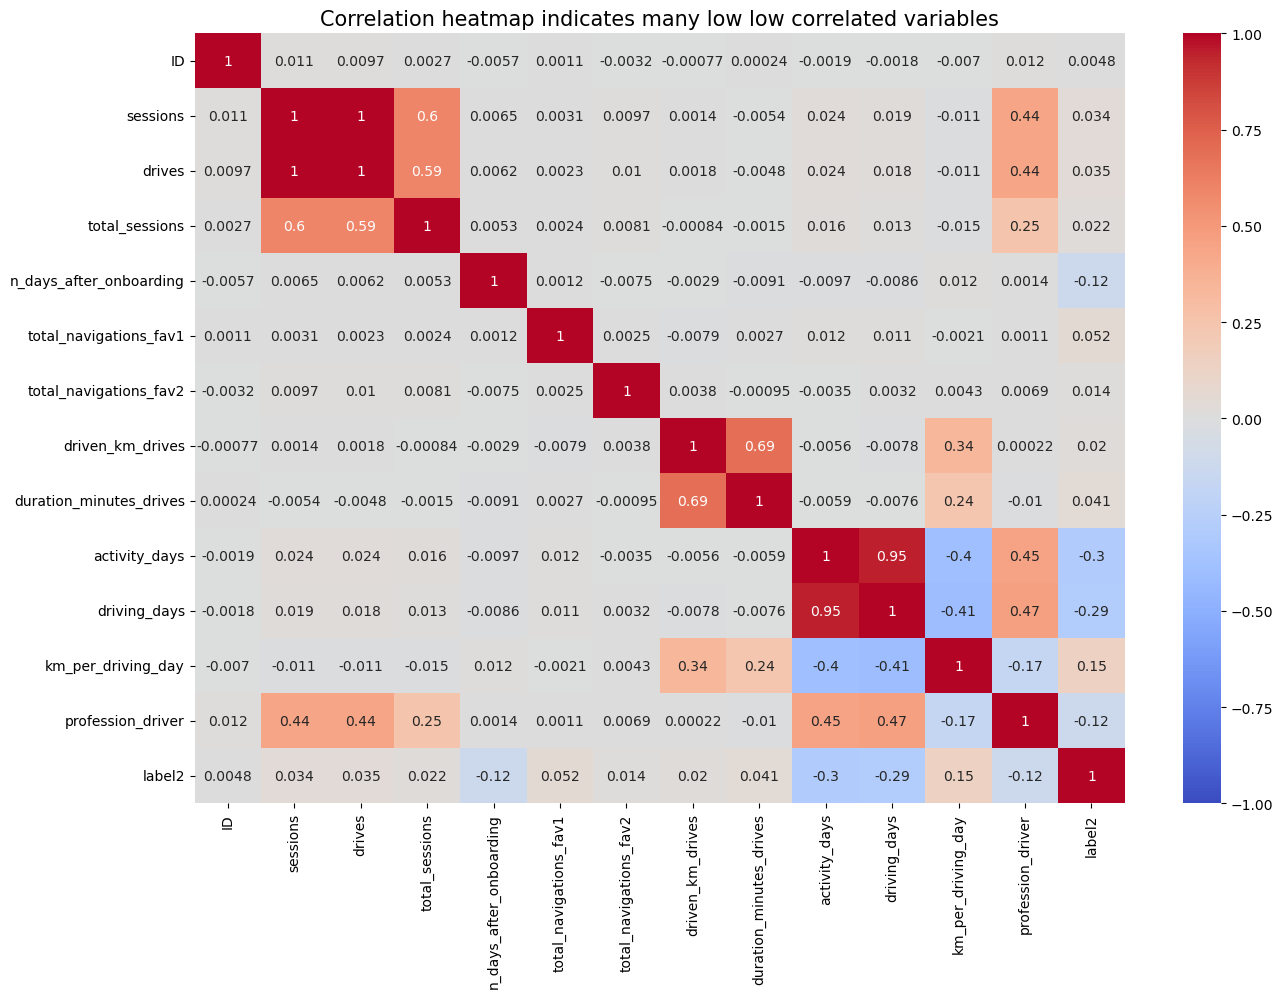

In [19]:
#Plot correlation heatmap
plt.figure(figsize=(15,10))
sns.heatmap(data=df.corr(method='pearson', numeric_only=True), 
            vmin=-1, vmax=1, cmap='coolwarm', annot=True)
plt.title("Correlation heatmap indicates many low low correlated variables", fontsize = 15)
plt.show()

If there are predictor variables that have a Pearson correlation coefficient value greater than the absolute value of 0.7, these variables are strongly multicollinear. Therefore, only one of these variables should be used in your model. 

Variables with multicollinearity:

1. sessions and drives: 1.0
2. driving_days and activity_days: 0.95

*3c Create dummies*

Create a new, binary column called `device2` that encodes user devices as follows:

* `Android` -> `0`
* `iPhone` -> `1`

In [20]:
#Create new `device2` variable
df['device2'] = np.where(df['device'] == 'iPhone', 1, 0)

In [21]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,profession_driver,label2,device2
0,0,retained,243,201,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267,1,0,0
1,1,retained,133,107,326.896596,1225,19,64,8889.794236,3160.472914,13,11,iPhone,1246.901868,0,0,1
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602,0,0,0
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374,0,0,1
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667,1,0,0


*3d. Assigning predictor variables and target*

In [22]:
#Isolate predictor variables
X = df.drop(columns = ['label', 'label2', 'device', 'sessions', 'driving_days'])

In [23]:
#Isolate target variable
y = df['label2']

In [24]:
#Split the data

#Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [25]:
X_train.head()

,ID,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,profession_driver,device2
3483,3483,50,90.468920,1039,0,15,6558.564887,1501.683515,2,0.000000,0,0
13354,13354,45,243.720232,1480,0,35,5657.864872,4660.502879,13,471.488739,0,0
6059,6059,48,61.511644,737,362,3,2575.235783,1407.662881,16,234.112344,0,0
198,198,13,186.979465,3306,184,32,905.681067,299.016399,10,90.568107,0,0
12381,12381,2,124.305442,802,0,0,2813.451801,2021.436512,0,0.000000,0,1


In [26]:
model = LogisticRegression(penalty=None, max_iter=400)

model.fit(X_train, y_train)

c:\Users\222817\anaconda3\envs\minimal_ds\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=400, penalty=None)

In [27]:
#Get the coefficients of each variable
pd.Series(model.coef_[0], index=X.columns)

ID                         0.000003
drives                     0.001970
total_sessions             0.000042
n_days_after_onboarding   -0.000389
total_navigations_fav1     0.001172
total_navigations_fav2     0.000953
driven_km_drives          -0.000033
duration_minutes_drives    0.000128
activity_days             -0.102080
km_per_driving_day         0.000007
profession_driver          0.010220
device2                   -0.038738
dtype: float64

In [28]:
#Get the intercept of the model
model.intercept_

array([-0.03097259])

In [29]:
#Check the final assumption

# Get the predicted probabilities of the training data
training_probabilities = model.predict_proba(X_train)
training_probabilities

array([[0.63086859, 0.36913141],
       [0.7938143 , 0.2061857 ],
       [0.78778067, 0.21221933],
       ...,
       [0.82656779, 0.17343221],
       [0.95642849, 0.04357151],
       [0.85094728, 0.14905272]])

In [30]:
#Copy the `X_train` dataframe and assign to `logit_data`
logit_data = X_train.copy()

#Create a new `logit` column in the `logit_data` df
logit_data['logit'] = [np.log(prob[1] / prob[0]) for prob in training_probabilities]

Text(0.5, 1.0, 'Log-odds: activity_days')

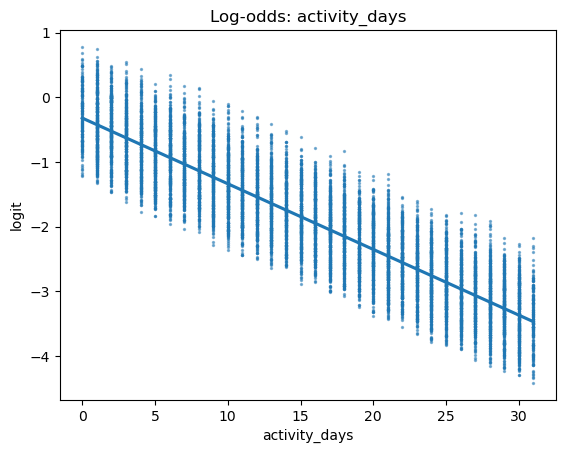

In [31]:
#Plot regplot of `activity_days` log-odds
sns.regplot(x = logit_data['activity_days'], y = logit_data['logit'], scatter_kws={'s': 2, 'alpha': 0.5})
plt.title('Log-odds: activity_days')

*4a. Results and Evaluation*

In [32]:
#Generate predictions on X_test
y_preds = model.predict(X_test)

In [33]:
#Score the model (accuracy) on the test data
model.score(X_test, y_test)

0.8309333333333333

*4b. Show results with a confusion matrix*

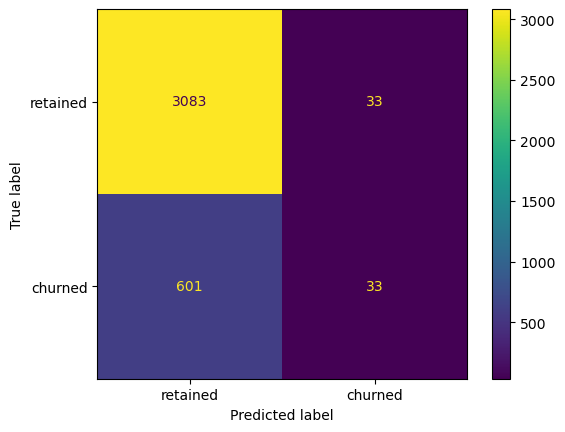

In [34]:
cm = confusion_matrix(y_test, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['retained', 'churned'])
disp.plot()

In [35]:
#Calculate precision manually
precision = cm[1, 1] / (cm[0, 1] + cm[1, 1])
precision

np.float64(0.5)

In [36]:
#Calculate recall manually
recall = cm[1,1] / (cm[1, 0] + cm[1, 1])
recall

np.float64(0.052050473186119876)

In [37]:
#Create a classification report
target_labels = ['retained', 'churned']
print(classification_report(y_test, y_preds, target_names=target_labels))

              precision    recall  f1-score   support

    retained       0.84      0.99      0.91      3116
     churned       0.50      0.05      0.09       634

    accuracy                           0.83      3750
   macro avg       0.67      0.52      0.50      3750
weighted avg       0.78      0.83      0.77      3750



The model has decent precision but very low recall, which means that it makes a lot of false negative predictions and fails to capture users who will churn.

In [38]:
#Generate a bar graph of the model's coefficients for a visual representation of the importance of the model's features.

#Create a list of (column_name, coefficient) tuples
feature_importance = list(zip(X_train.columns, model.coef_[0]))

#Sort the list by coefficient value
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)
feature_importance

[('profession_driver', np.float64(0.010219944061603805)),
 ('drives', np.float64(0.001970055043053564)),
 ('total_navigations_fav1', np.float64(0.0011724401852575472)),
 ('total_navigations_fav2', np.float64(0.0009525033890281597)),
 ('duration_minutes_drives', np.float64(0.0001283330111561261)),
 ('total_sessions', np.float64(4.156060413091386e-05)),
 ('km_per_driving_day', np.float64(7.178744206480264e-06)),
 ('ID', np.float64(2.8583708038879778e-06)),
 ('driven_km_drives', np.float64(-3.294355056667037e-05)),
 ('n_days_after_onboarding', np.float64(-0.0003888069315483)),
 ('device2', np.float64(-0.0387379471022674)),
 ('activity_days', np.float64(-0.10208048643850252))]

Text(0.5, 1.0, 'Feature Importance')

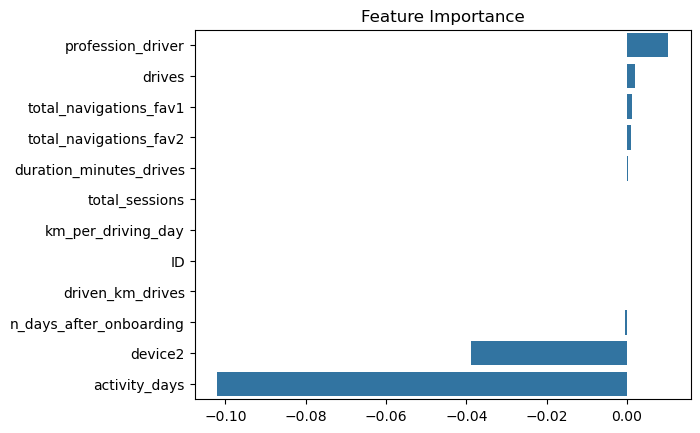

In [39]:
#Plot the feature importances
sns.barplot(x = [x[1] for x in feature_importance],
            y = [x[0] for x in feature_importance],
            orient='h')
plt.title('Feature Importance')

*4c. Conclusion*

1. `activity_days` was by far the most important feature in the model. It had a negative correlation with user churn. This was not surprising, as this variable was very strongly correlated with `driving_days`, which was known from EDA to have a negative correlation with churn.

2. In previous EDA, user churn rate increased as the values in `km_per_driving_day` increased. The correlation heatmap here in this notebook revealed this variable to have the strongest positive correlation with churn of any of the predictor variables by a relatively large margin. In the model, it was the second-least-important variable.

3. In a multiple logistic regression model, features can interact with each other and these interactions can result in seemingly counterintuitive relationships. This is both a strength and a weakness of predictive models, as capturing these interactions typically makes a model more predictive while at the same time making the model more difficult to explain.

4. It would be helpful to have drive-level information for each user (such as drive times, geographic locations, etc.). It would probably also be helpful to have more granular data to know how users interact with the app. For example, how often do they report or confirm road hazard alerts? Finally, it could be helpful to know the monthly count of unique starting and ending locations each driver inputs.